# Peer-to-peer Loan Data Analysis 💰 - I

### 📊 Exploratory Data Analysis & Visualisations using **Matplotlib**

## Scenario - 1

We're working with a startup looking to disrupt peer-to-peer lending with a new product. Their plan is to develop a state-of-the-art risk management strategy for providing loans to different communities across the United States. We're working with a data set of loans from LendingTree, a peer-to-peer lending platform. 

**Goal:** Develop a state-of-the-art risk management strategy for providing loans to different communities across the United States.

**Dataset:** Loans from Lending Tree, a peer-to-peer lending platform.

**Task:** Conducting exploratory data analysis to better understand the characteristics of loans with different levels of risk.
- Develop a report of findings to share with the bank
- Develop insightful visualizations to help client understand different risk profiles

### Exploratory Data Analysis & Visualisations

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("loan_data.csv")

In [157]:
df.head()

,emp_title,emp_length,state,homeownership,debt_to_income,annual_income,open_credit_lines,total_credit_limit,total_credit_utilized,total_debit_limit,loan_amount,interest_rate,installment,grade,balance,paid_interest
0,administrative assistant,0,FL,RENT,22.51,32000.0,4,22984,18420,5000,2500,7.96,78.30,A,2326.16,31.65
1,sole proprietor,10,MN,OWN,2.99,45000.0,5,203255,1469,9000,12500,7.34,387.91,A,11559.92,218.55
2,pension ananlyst,10,MD,OWN,21.07,90000.0,19,154848,62112,79300,13000,7.35,403.49,A,11360.72,364.90
3,director of corporate operations,0,MN,MORTGAGE,12.28,130000.0,23,296496,77944,93600,17500,7.35,349.42,A,16273.90,470.99
4,dispatcher,3,TX,RENT,28.97,65000.0,28,156207,70381,50800,8000,7.96,250.55,A,7403.61,151.72


### Visualising Loan Grades

1. We start by visualizing the loan grades, so we can better understand the **composition of the entire portfolio of loans.**

In [8]:
# Check the values of grade column

print(df["grade"].unique())

['A' 'B' 'C' 'D' 'E' 'F' 'G']


*Loans are assigned a grade from **A to G**, with A-grade loans having the lowest expected risk of loss, ​and typically the lowest interest rates.*

2. **Checking the frequency of loan grades:** To graph the **frequency of the different loan grades**, we can use the `.valueCounts()` method to create a series with the count of each grade in the data set. Then use the `.plot()` method with kind equals `bar` to create a chart. 

<Axes: xlabel='grade'>

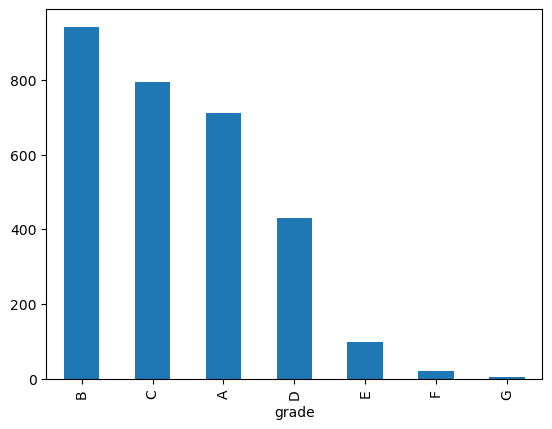

In [11]:
df["grade"].value_counts().plot(kind="bar")

*We can see that B-grade loans are the most common, followed by C, then A, with only a few loans of grades E, F, and G.*


3. **Sorting by index:** Since the Grades column has an **order** to it, it would help to order these grades appropriately.
   We can use the `sort_index()` method, which sorts the data by the index. We will call the `sort_index()` method on the result of `value_counts()`, which is a series; this sorts the series by the letter grades, A to G. 

In [16]:
sorted_grades = df["grade"].value_counts().sort_index()

<Axes: xlabel='grade'>

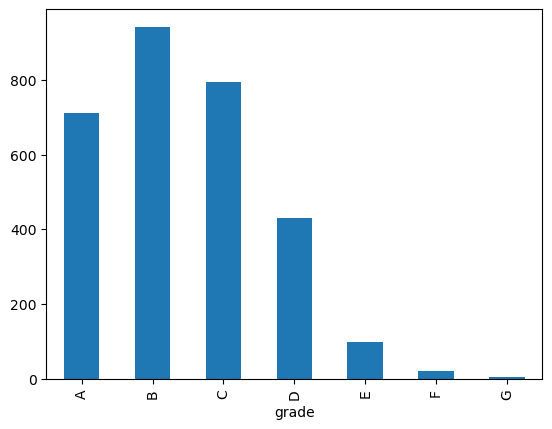

In [17]:
sorted_grades.plot(kind="bar")

*So, our client may conclude they should be **cautious** about giving out loans that would receive a **grade of E, F, or G,** since these are rarely given out by their competitor lending tree.*

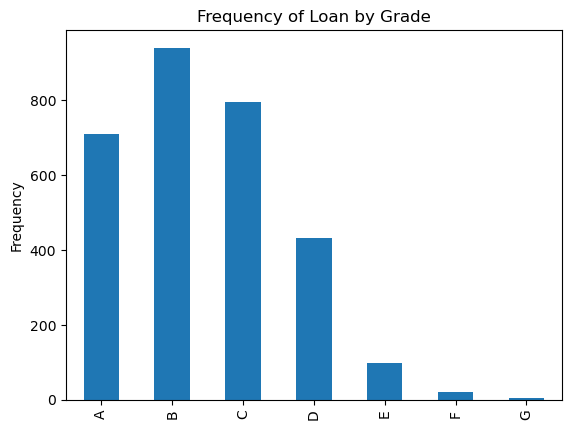

In [18]:
# Enhancing the chart using matplotlib

sorted_grades.plot(kind="bar")
plt.title("Frequency of Loan by Grade")
plt.xlabel("")  # empty string removes x label
plt.ylabel("Frequency")
plt.show()

4. **Improving chart's readability:** We want to improve the chart's readability and save this plot as an image to add to our report.

* We want to add the columns as a **gradient of green to red** - to add double encoding. This gradient will help our clients quickly interpret the chart.

* I took the LLM's help for this using the following prompt: "Use HTML color names (subtle ones) to create a list of seven colors in Python code that progress from green to red, passing through orange and yellow."

In [32]:
colors = colors = ['mediumseagreen', 'olivedrab', 'darkkhaki', 'goldenrod', 'peru', 'indianred', 'rosybrown']

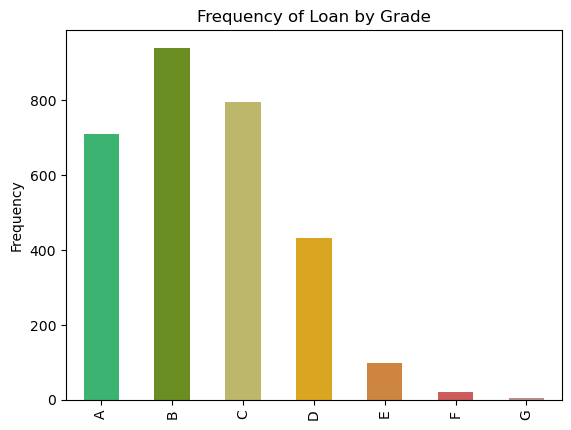

In [33]:
sorted_grades.plot(kind="bar", color=colors)
plt.title("Frequency of Loan by Grade")
plt.xlabel("")  # empty string removes x label
plt.ylabel("Frequency")
plt.show()

* To improve the readability of this chart even more, we can add a grid.


* Although, it's pretty redundant to have a grid on the x-axis. Since the bar color and the labels help the viewer understand the loan grade. So, we can use the named argument `axis=y` to remove the x-axis grid lines.

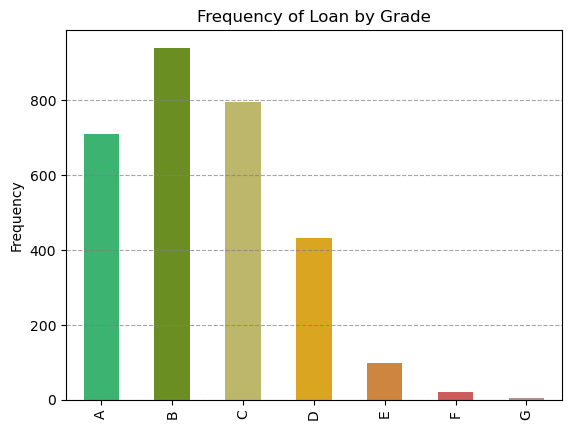

In [34]:
sorted_grades.plot(kind="bar", color=colors)
plt.title("Frequency of Loan by Grade")
plt.xlabel("")  
plt.ylabel("Frequency")
plt.grid(axis="y", color="grey", alpha=0.7, linestyle="--")   # deafult for axis: "both"
plt.show()

5. **Saving the figure:** We can now save our figure to a file, using the function `plot.savefig()` 

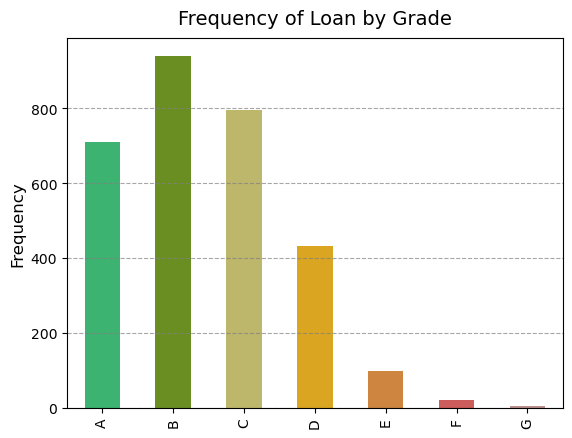

In [44]:
sorted_grades.plot(kind="bar", color=colors)
plt.title("Frequency of Loan by Grade", fontsize=14, pad=10)
plt.xlabel("")  
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis="y", color="grey", alpha=0.7, linestyle="--")
plt.savefig("loan_column_chart.png")

6. **Adding Annotations:** Through our research, we have discovered that loans that are **below grade D** are at a **very high risk of default.** We can add this information to the chart to help our clients understand why there is a sharp drop-off for loans below grade D. We can use `plot.annotate()`.

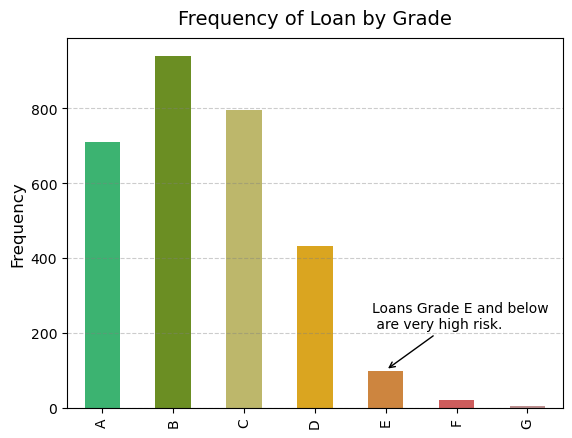

In [76]:
sorted_grades.plot(kind="bar", color=colors)

plt.title("Frequency of Loan by Grade", fontsize=14, pad=10)
plt.xlabel("")  
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis="y", color="grey", alpha=0.4, linestyle="--")

# Add annotations for high-risk loans
plt.annotate(text="Loans Grade E and below\n are very high risk.",
             xy=(4, 100),                 # Coordinates of the point to annotate
             xytext=(-10, 30),            # Position of the text
             textcoords="offset points",  # Coordinate system for the offset
             arrowprops=dict(color='black', arrowstyle="->")  # Arrow properties
)

plt.show()

7. **Frequency labels:** Adding labels for frequency on top of each bar.
* Also, we save the plot to a variable `ax`.

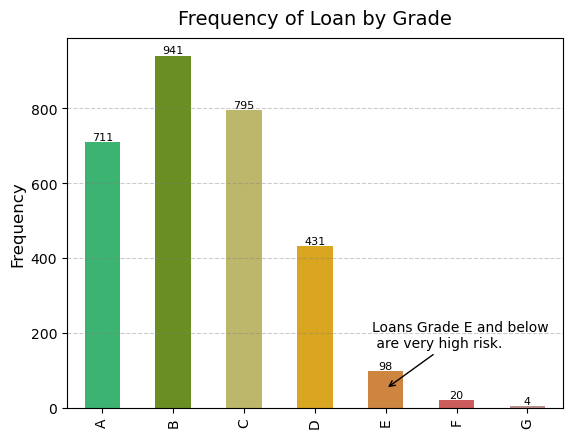

In [85]:
ax = sorted_grades.plot(kind="bar", color=colors)   # to save plot to a variable

plt.title("Frequency of Loan by Grade", fontsize=14, pad=10)
plt.xlabel("")  
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis="y", color="grey", alpha=0.4, linestyle="--")
plt.annotate(text="Loans Grade E and below\n are very high risk.",
             xy=(4, 50),                
             xytext=(-10, 30),           
             textcoords="offset points",  
             arrowprops=dict(color='black', arrowstyle="->")  
)

# Add frequency labels on top of each bar
for bar in ax.patches:
    bar_height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar_height,
            f"{bar_height:.0f}",
            ha="center",
            va="bottom",
            fontsize=8)
    
plt.show()

8. **Adjusting Minor ticks:** If we want to add additional minor ticks, we have to import a MapPlotLib tool called AutoMinorLocator. It helps to automatically locate the minor ticks on your axis.

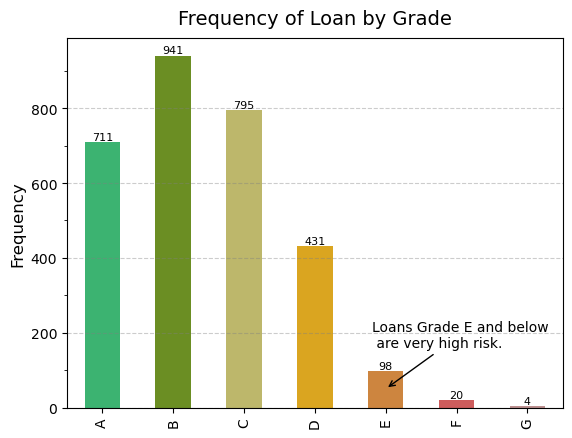

In [89]:
from matplotlib.ticker import AutoMinorLocator

ax = sorted_grades.plot(kind="bar", color=colors)

plt.title("Frequency of Loan by Grade", fontsize=14, pad=10)
plt.xlabel("")  
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis="y", color="grey", alpha=0.4, linestyle="--")

# Adding additional ticks to our y-axis
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

plt.annotate(text="Loans Grade E and below\n are very high risk.",
             xy=(4, 50), 
             xytext=(-10, 30),          
             textcoords="offset points",  
             arrowprops=dict(color='black', arrowstyle="->")  
)
for bar in ax.patches:
    bar_height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar_height,
            f"{bar_height:.0f}",
            ha="center",
            va="bottom",
            fontsize=8)
    
plt.show()

9. **A minimalistic version:** If our client needs a minimalist graph, we might want to modify this graph even more to remove the **spines** or the boundaries here, as well as the ticks and Y label.

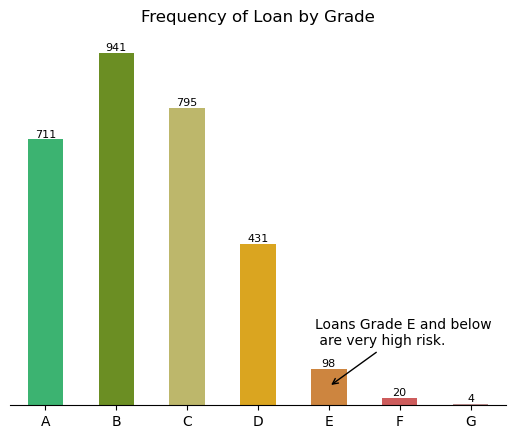

In [97]:
ax = sorted_grades.plot(kind="bar", color=colors)

plt.title("Frequency of Loan by Grade", fontsize=12, pad=10)
plt.xlabel("")  
plt.ylabel("")

# Removing the spines
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)

# Removing the y-axis ticks
ax.yaxis.set_ticks([])

# Rotating the x-axis labels
plt.xticks(rotation=0)

plt.annotate(text="Loans Grade E and below\n are very high risk.",
             xy=(4, 50), 
             xytext=(-10, 30),          
             textcoords="offset points",  
             arrowprops=dict(color='black', arrowstyle="->")  
)
for bar in ax.patches:
    bar_height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar_height,
            f"{bar_height:.0f}",
            ha="center",
            va="bottom",
            fontsize=8)
    
plt.savefig("loan_column_chart_minimal.png")

## Scenario - 2

**Goal:** Identify key characteristics of loans from states with highest average loan amount:
- District of Columbia
- Alaska
- Hawaii

**Task:** Plot the loan amount by grade across these three states using a grouped bar chart.


**Grouped column charts** allow us to compare a numerical feature across multiple categorical ones.

### Exploratory Data Analysis & Visualisations

1. **Set up our data:** Filter data to only include top three states
   

In [100]:
# Names of the top 3 states for loan amount
states = ["DC", "AK", "HI"]

In [104]:
filtered_df = df[df["state"].isin(states)]

In [106]:
filtered_df.sample(5)

,emp_title,emp_length,state,homeownership,debt_to_income,annual_income,open_credit_lines,total_credit_limit,total_credit_utilized,total_debit_limit,loan_amount,interest_rate,installment,grade,balance,paid_interest
244,manager,9,AK,OWN,12.31,35000.0,19,421180,8701,113300,19000,6.71,584.15,A,17558.24,303.61
1966,vp of operations,2,DC,MORTGAGE,17.42,135000.0,8,372772,101338,26100,16800,16.02,408.73,C,16047.29,867.26
1490,management,5,DC,RENT,34.91,187000.0,22,330513,212441,91500,10000,11.98,332.05,B,9533.25,184.04
601,forman,4,AK,RENT,15.27,90000.0,5,80384,53209,32500,36000,6.71,1106.81,A,33268.25,561.84
1761,bilingual case manager,2,DC,OWN,24.03,95000.0,11,122000,44762,70600,35000,12.62,1172.90,C,30890.38,1730.34


2. **Create Groups for states and grades**:  Group by each state and grade
  

In [112]:
grouped_df=filtered_df.groupby(["state", "grade"])  #order matters
grouped_df

* *This is a `groupby object`, and so we can't actually see it. It's an **intermediate data structure**. We'll need to do the next step first - Aggregate the loan amount by averaging it.*

3. **Aggregate the loan amount**: Select loan amount column and calculate mean for each group

In [114]:
grouped_loan_amount=filtered_df.groupby(["state", "grade"])["loan_amount"].mean()
grouped_loan_amount

state  grade
AK     A        25750.000000
       B        30833.333333
       C        12500.000000
       D        11100.000000
DC     A        40000.000000
       B        12500.000000
       C        25900.000000
HI     A         1200.000000
       B        17733.333333
       D        10000.000000
       E        31666.666667
       F        28000.000000
Name: loan_amount, dtype: float64

* *Now, we have the state and the grade and the average loan amount for that state and grade. This feature is called a **multi-index** in Pandas.*

* *If we try graphing this directly, using `.plot`, kind equals `bar`, we get these **double indices**, and they're all separated into their own columns. This chart isn't a true group bar chart.*

4. **Creating the Grouped Column Chart**: Create a grouped column chart showing the mean value of loans of each grade.

<Axes: xlabel='state,grade'>

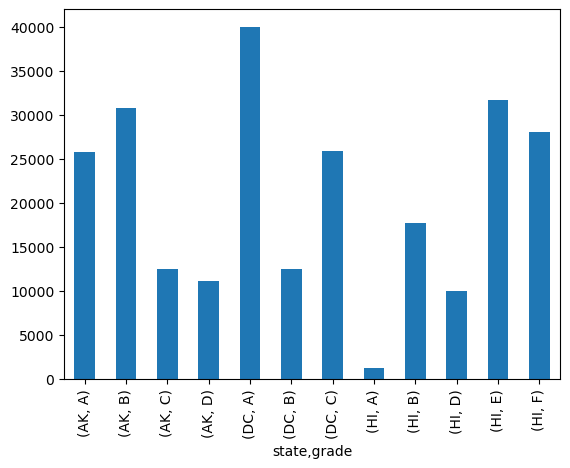

In [116]:
grouped_loan_amount.plot(kind="bar")

* We have to use the `unstack()` method to separate out the grades into columns.  


In [119]:
grouped_loan_amount.unstack()

grade,A,B,C,D,E,F
state,,,,,,
AK,25750.0,30833.333333,12500.0,11100.0,NaN,NaN
DC,40000.0,12500.000000,25900.0,NaN,NaN,NaN
HI,1200.0,17733.333333,NaN,10000.0,31666.666667,28000.0


*Some of the values are **NaN**, because for some of these combinations, there wasn't a single loan.*

* `unstack()` behaves similarly to the **pivot methods**.
* If we have two rows of indices, like state and grade, it moves the second set of indices out to become columns instead. Now we end up with a single index and the rest of the data captured in the columns of the unstacked data frame.
* Once we've unstacked our data, we can use `.plot`, kind equals `bar`, and the columns are grouped by the index automatically. 

<Axes: xlabel='state'>

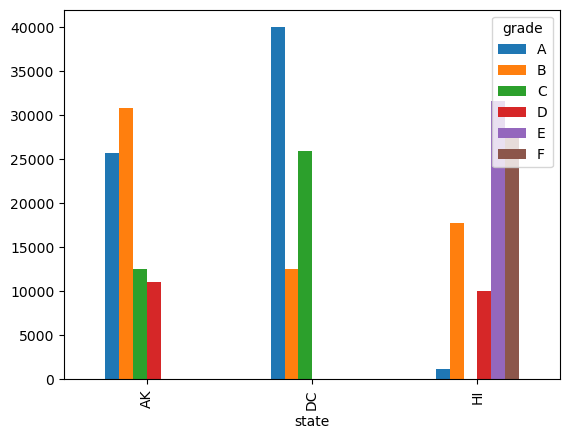

In [118]:
grouped_loan_amount.unstack().plot(kind="bar")

* We have this really nice setup where each state has an average loan amount for each grade.
* And now we're back to having just a **single index**, the **state**.

5. **Improving the Chart's Readability**
    * We'll need a title and axis labels.
    * The labels can be rotated to be horizontal.
    * The legend can be moved outside the chart. It's obscuring the data.

* ***Moving the legend:***
    * In order to move the legend outside the chart, we use `plot.legend()` with the argument `bbox_to_anchor`.
    * `bbox` stands for **bounding box**, or the invisible box that contains the legend.
    * So the question is, where do we put this box relative to the axes or relative to the plot? This function takes in an argument that specifies a point of xy-coordinates; we consider (1,1) here. We can think of this whole bottom spine as having values from 0 to 1, and same for the left spine. So putting the legend at coordinates 1, 1 puts it outside the plot on the right. 

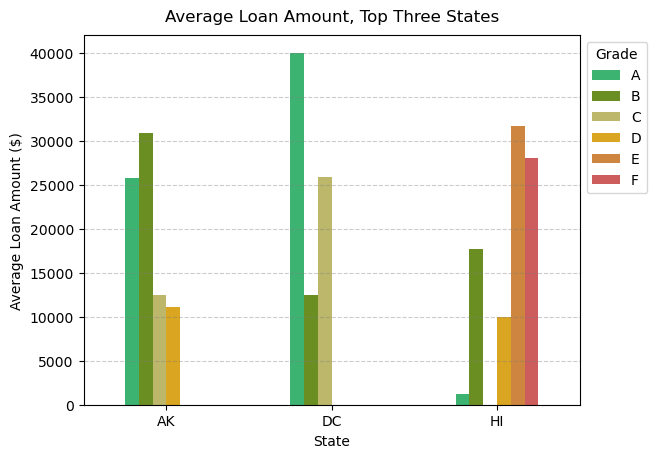

In [128]:
grouped_loan_amount.unstack().plot(kind="bar",
                                  color=colors)

plt.title("Average Loan Amount, Top Three States", fontsize=12, pad=10)
plt.xlabel("State")
plt.ylabel("Average Loan Amount ($)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4, color="grey") 
    
# Moving the legend outside the plot
plt.legend(title="Grade", bbox_to_anchor=(1,1))

plt.savefig("grouped_by_state_and_grade.png")

### **Interpretations:** 
   * Hawaii looks quite different from both Alaska and DC.
   * While Alaska and DC had primarily low-risk loans, Hawaii had large but higher-risk loans, suggesting that there are different patterns in these different states.
   * DC also seems to have a high average value for its A-grade loans, suggesting that may be a profitable strategy for our client.

## Scenario-3

**Goal:** Understand whether the composition of homeownership changes based on the risk profile of the loan. 

**Task:** We want to highlight the **proportion of renters** for each group. 

We are interested in exploring the total loan amount by:
* Grade
* Homeownership status

A **Stacked column chart** is ideal in this case because we want to compare the composition of loan amounts within each grade. We'll perform similar steps as with a group column chart:
* Grouping our data
* Aggregating it
* Unstacking it before plotting. 

### Exploratory Data Analysis & Visualisations

1. **Grouping, aggregating and unstacking** the data to plot

In [159]:
df.head()

,emp_title,emp_length,state,homeownership,debt_to_income,annual_income,open_credit_lines,total_credit_limit,total_credit_utilized,total_debit_limit,loan_amount,interest_rate,installment,grade,balance,paid_interest
0,administrative assistant,0,FL,RENT,22.51,32000.0,4,22984,18420,5000,2500,7.96,78.30,A,2326.16,31.65
1,sole proprietor,10,MN,OWN,2.99,45000.0,5,203255,1469,9000,12500,7.34,387.91,A,11559.92,218.55
2,pension ananlyst,10,MD,OWN,21.07,90000.0,19,154848,62112,79300,13000,7.35,403.49,A,11360.72,364.90
3,director of corporate operations,0,MN,MORTGAGE,12.28,130000.0,23,296496,77944,93600,17500,7.35,349.42,A,16273.90,470.99
4,dispatcher,3,TX,RENT,28.97,65000.0,28,156207,70381,50800,8000,7.96,250.55,A,7403.61,151.72


In [140]:
grouped_df = df.groupby(["grade", "homeownership"])["loan_amount"].sum().unstack()
grouped_df

homeownership,MORTGAGE,OWN,RENT
grade,,,
A,6972200,1343400,3176775
B,9081100,2056225,4655775
C,6925450,1383300,5005850
D,3216450,1329075,2718175
E,973275,190000,700025
F,237300,72900,136600
G,25000,20300,43750


***Sum** makes sense here rather than **mean** because we're interested in seeing what **proportion** of money comes from customers with different profiles.*

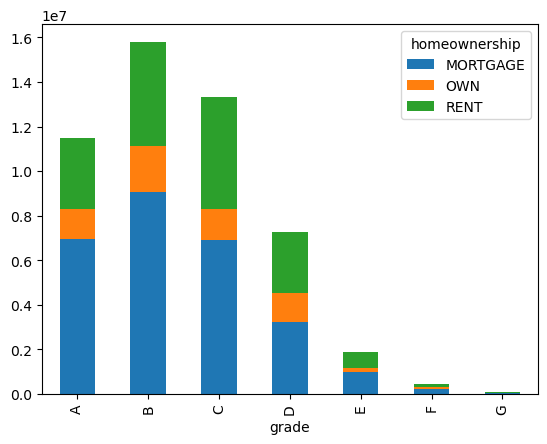

In [143]:
grouped_df.plot(kind="bar",
               stacked=True)
plt.show()

2. **Improving redability**

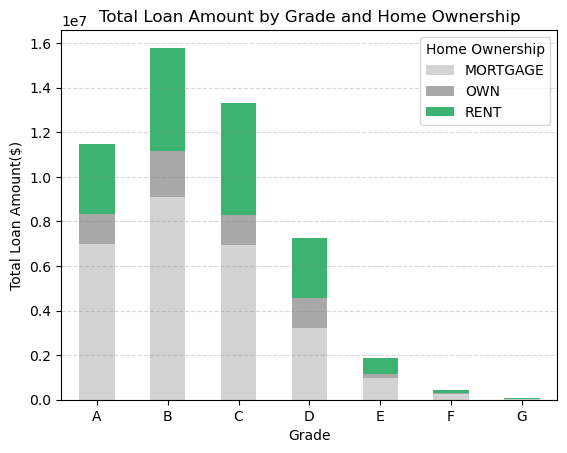

In [148]:
grouped_df.plot(kind="bar",
                stacked=True,
                color=["lightgrey", "darkgrey", "mediumseagreen"])  #change color to highlight renters

plt.title("Total Loan Amount by Grade and Home Ownership", fontsize=12)
plt.xlabel("Grade")
plt.ylabel("Total Loan Amount($)")
plt.grid(axis="y", linestyle="--", alpha=0.3, color="grey")
plt.xticks(rotation=0)
plt.legend(title="Home Ownership")


plt.show()

3. Creating a **100% stacked chart**
* We take the LLM's help: *"Modify this code to create a new version of this chart as a stack column chart ​with proportion on the y-axis and each column the same height."*

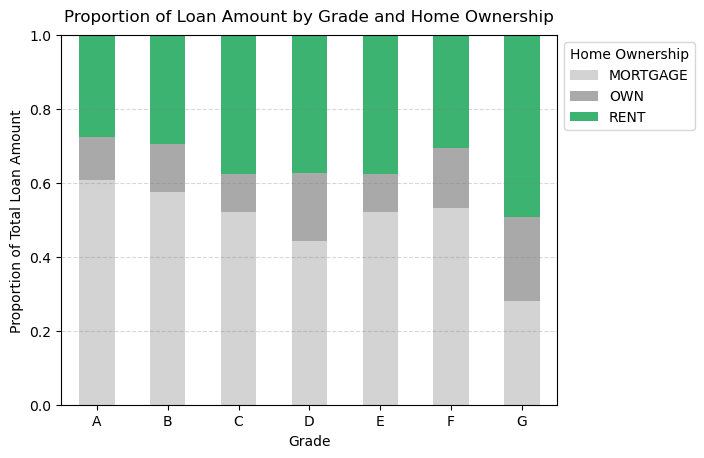

In [154]:
# Calculate the proportion for each group
grouped_df_prop = grouped_df.div(grouped_df.sum(axis=1), axis=0)

# Create the stacked column chart with proportions
grouped_df_prop.plot(kind="bar", 
                    stacked=True,
                    color=["lightgrey", "darkgrey", "mediumseagreen"])

plt.title("Proportion of Loan Amount by Grade and Home Ownership", fontsize=12, pad=10)
plt.xlabel("Grade")
plt.ylabel("Proportion of Total Loan Amount")
plt.grid(axis="y", linestyle="--", alpha=0.3, color="grey")
plt.xticks(rotation=0)
plt.legend(title="Home Ownership", bbox_to_anchor=(1,1))
plt.ylim(0, 1)  # Set y-axis limits from 0 to 1

plt.savefig("loans_by_grades_and_homeownership.png")

### Interpretation:
* The proportion of renters is relatively consistent across grades A and B, but increases in the C, D, and E grades.
* This can provide our clients some insights about what type of collateral their customers might have for different loan grades.

## Scenario - 4

**Findings:**  
* We've investigated **correlations** between many of the features in our dataset, and have found that **annual income** is a moderate predictor of **total credit limit**, with a **Pearson correlation coefficient of 0.55**.

**Tasks:**

1. Graph this relationship to help our clients understand how the income distribution of their customers might impact the amount of credit they should offer.
2. Visualizing the credit limits of customers who make incomes in the top 5% of the distribution.

A **scatterplot** is an appropriate chart type for this task, since we're looking to visualize the relationship between two numerical features.

### Exploratory Data Analysis & Visualisations

In [158]:
df.head()

,emp_title,emp_length,state,homeownership,debt_to_income,annual_income,open_credit_lines,total_credit_limit,total_credit_utilized,total_debit_limit,loan_amount,interest_rate,installment,grade,balance,paid_interest
0,administrative assistant,0,FL,RENT,22.51,32000.0,4,22984,18420,5000,2500,7.96,78.30,A,2326.16,31.65
1,sole proprietor,10,MN,OWN,2.99,45000.0,5,203255,1469,9000,12500,7.34,387.91,A,11559.92,218.55
2,pension ananlyst,10,MD,OWN,21.07,90000.0,19,154848,62112,79300,13000,7.35,403.49,A,11360.72,364.90
3,director of corporate operations,0,MN,MORTGAGE,12.28,130000.0,23,296496,77944,93600,17500,7.35,349.42,A,16273.90,470.99
4,dispatcher,3,TX,RENT,28.97,65000.0,28,156207,70381,50800,8000,7.96,250.55,A,7403.61,151.72


* **Task 1:** Graph the relationship between annual income and total credit limit

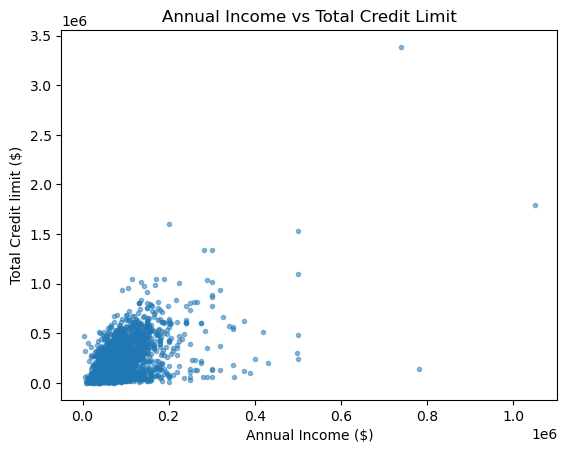

In [4]:
plt.scatter(df["annual_income"], df["total_credit_limit"], alpha=0.5, marker=".")

plt.title("Annual Income vs Total Credit Limit", fontsize=12)
plt.xlabel("Annual Income ($)")
plt.ylabel("Total Credit limit ($)")
plt.show()

*This graph is pretty sparse, with just a handful of outliers, three to be precise, taking up the plot.* 

*We should control the x and y limits of the plot, effectively zooming in on different parts of the plot. We can zoom in on the x values on the left half of the chart, because the values look like they're between 0 and 0.5.*

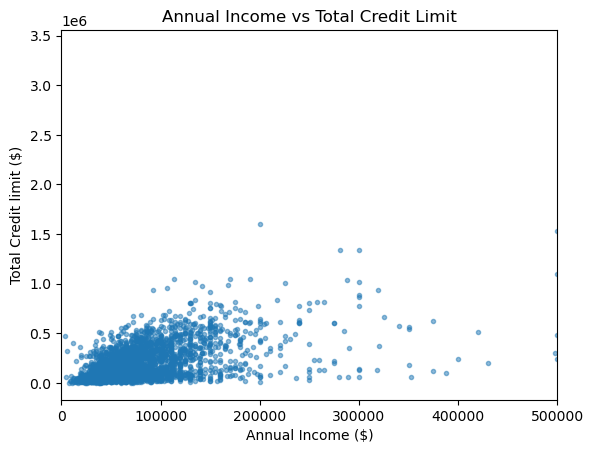

In [5]:
plt.scatter(df["annual_income"], df["total_credit_limit"], alpha=0.5, marker=".")

plt.title("Annual Income vs Total Credit Limit", fontsize=12)
plt.xlabel("Annual Income ($)")
plt.ylabel("Total Credit limit ($)")
plt.xlim(0,500000)      # specify lower and upper bounds
plt.show()

* **Task 2:** Visualizing the credit limits of customers who make incomes in the top 5% of the distribution by drawing a cutoff point on our scatterplot, a vertical line separating the distribution into 95% and 5%. 


In [6]:
# Find top 5% incomes
top_5_percent_income = df["annual_income"].quantile(0.95)
print(top_5_percent_income)

170000.0


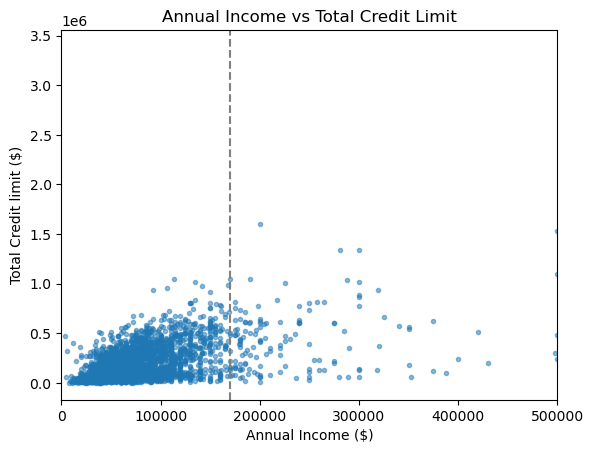

In [7]:
plt.scatter(df["annual_income"], df["total_credit_limit"], alpha=0.5, marker=".")

plt.title("Annual Income vs Total Credit Limit", fontsize=12)
plt.xlabel("Annual Income ($)")
plt.ylabel("Total Credit limit ($)")
plt.xlim(0,500000)     
plt.axvline(x=top_5_percent_income, color="grey", linestyle="--")
plt.show()

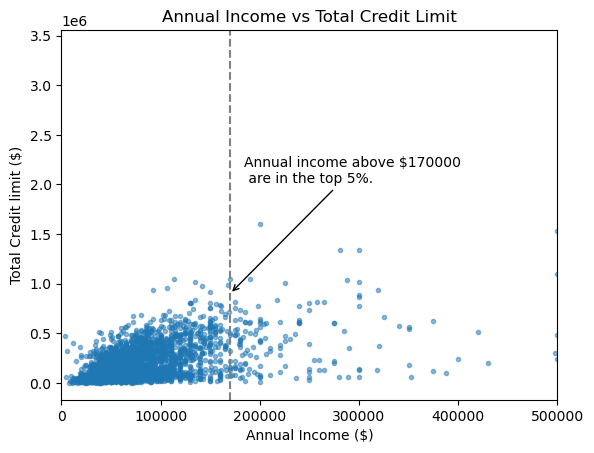

In [25]:
plt.scatter(df["annual_income"], df["total_credit_limit"], alpha=0.5, marker=".")

plt.title("Annual Income vs Total Credit Limit", fontsize=12)
plt.xlabel("Annual Income ($)")
plt.ylabel("Total Credit limit ($)")
plt.xlim(0,500000)     
plt.axvline(x=top_5_percent_income, color="grey", linestyle="--")

plt.annotate(text="Annual income above $170000\n are in the top 5%.",
             xy=(170000, 900000), 
             xytext=(10, 80),          
             textcoords="offset points",  
             arrowprops=dict(color='black', arrowstyle="->")  
)

plt.savefig("annual_income_vs_total_credit_limit.png")